# DATA ANALYSIS PRACTICE USING NETFLIX DATA

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


Matplotlib is building the font cache; this may take a moment.


In [4]:
# Import dataset
df = pd.read_csv('data/netflix1.csv')
df = pd.read_csv('data/netflix1.csv', parse_dates=['date_added'])
df.head()

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,2021-09-22,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


In [5]:
# view last five entries
df.tail()

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
8785,s8797,TV Show,Yunus Emre,Not Given,Turkey,2017-01-17,2016,TV-PG,2 Seasons,"International TV Shows, TV Dramas"
8786,s8798,TV Show,Zak Storm,Not Given,United States,2018-09-13,2016,TV-Y7,3 Seasons,Kids' TV
8787,s8801,TV Show,Zindagi Gulzar Hai,Not Given,Pakistan,2016-12-15,2012,TV-PG,1 Season,"International TV Shows, Romantic TV Shows, TV ..."
8788,s8784,TV Show,Yoko,Not Given,Pakistan,2018-06-23,2016,TV-Y,1 Season,Kids' TV
8789,s8786,TV Show,YOM,Not Given,Pakistan,2018-06-07,2016,TV-Y7,1 Season,Kids' TV


In [6]:
# View the shape
rows, cols = df.shape

print(f'Rows: {rows}')
print(f'Cols: {cols}')

Rows: 8790
Cols: 10


In [7]:
# view first 5 entries
df.head()

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,2021-09-22,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


In [8]:
# View Descriptive statistics
df.describe(include = 'all')   # include all columns
df.describe()

,date_added,release_year
count,8790,8790.000000
mean,2019-05-17 21:44:01.638225,2014.183163
min,2008-01-01 00:00:00,1925.000000
25%,2018-04-06 00:00:00,2013.000000
50%,2019-07-03 00:00:00,2017.000000
75%,2020-08-19 18:00:00,2019.000000
max,2021-09-25 00:00:00,2021.000000
std,NaN,8.825466


In [9]:
# Give column Names, non-null counts, data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8790 non-null   str           
 1   type          8790 non-null   str           
 2   title         8790 non-null   str           
 3   director      8790 non-null   str           
 4   country       8790 non-null   str           
 5   date_added    8790 non-null   datetime64[us]
 6   release_year  8790 non-null   int64         
 7   rating        8790 non-null   str           
 8   duration      8790 non-null   str           
 9   listed_in     8790 non-null   str           
dtypes: datetime64[us](1), int64(1), str(8)
memory usage: 686.8 KB


In [10]:
#check for null values
df.isnull().sum()

show_id         0
type            0
title           0
director        0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
dtype: int64

In [11]:
# check for duplicates
df.duplicated().sum()

np.int64(0)

In [12]:
df['type'].unique()

<StringArray>
['Movie', 'TV Show']
Length: 2, dtype: str

In [13]:
df['type'].value_counts()

type
Movie      6126
TV Show    2664
Name: count, dtype: int64

In [14]:
df['country'].unique()

<StringArray>
[       'United States',               'France',               'Brazil',
       'United Kingdom',                'India',              'Germany',
             'Pakistan',            'Not Given',                'China',
         'South Africa',                'Japan',              'Nigeria',
                'Spain',          'Philippines',            'Australia',
            'Argentina',               'Canada',            'Hong Kong',
                'Italy',          'New Zealand',                'Egypt',
             'Colombia',               'Mexico',              'Belgium',
          'Switzerland',               'Taiwan',             'Bulgaria',
               'Poland',          'South Korea',         'Saudi Arabia',
             'Thailand',            'Indonesia',               'Kuwait',
             'Malaysia',              'Vietnam',              'Lebanon',
              'Romania',                'Syria', 'United Arab Emirates',
               'Sweden',            '

In [15]:
country_count = df['country'].value_counts()
country_count

country
United States     3240
India             1057
United Kingdom     638
Pakistan           421
Not Given          287
                  ... 
Luxembourg           1
Senegal              1
Belarus              1
Puerto Rico          1
Cyprus               1
Name: count, Length: 86, dtype: int64

<Axes: title={'center': 'Frequency count of countries'}, xlabel='country'>

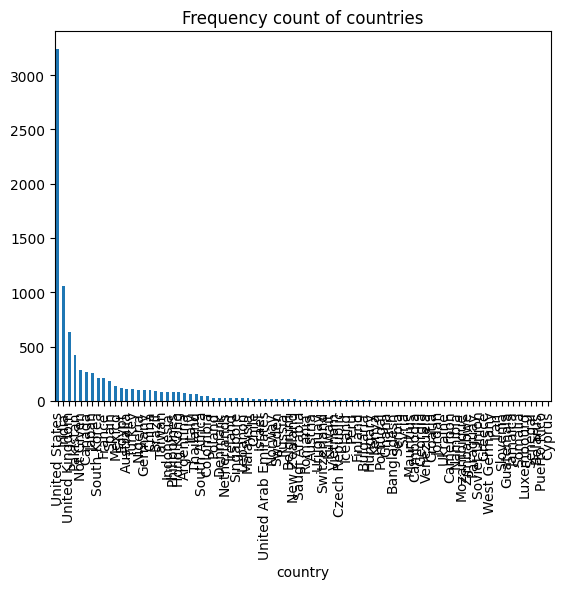

In [16]:
country_count.plot(kind='bar', title='Frequency count of countries')

<Axes: title={'center': 'Frequency count of countries'}, xlabel='country'>

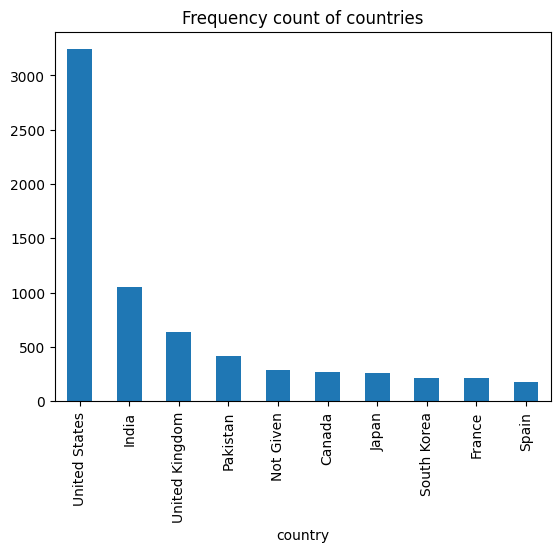

In [17]:
# content by country 
country_count.head(10).plot(kind='bar', title='Frequency count of countries')

In [18]:
df.describe()

,date_added,release_year
count,8790,8790.000000
mean,2019-05-17 21:44:01.638225,2014.183163
min,2008-01-01 00:00:00,1925.000000
25%,2018-04-06 00:00:00,2013.000000
50%,2019-07-03 00:00:00,2017.000000
75%,2020-08-19 18:00:00,2019.000000
max,2021-09-25 00:00:00,2021.000000
std,NaN,8.825466


In [19]:
df['rating'].unique()

<StringArray>
[   'PG-13',    'TV-MA',    'TV-PG',    'TV-14',    'TV-Y7',     'TV-Y',
       'PG',     'TV-G',        'R',        'G',    'NC-17',       'NR',
 'TV-Y7-FV',       'UR']
Length: 14, dtype: str

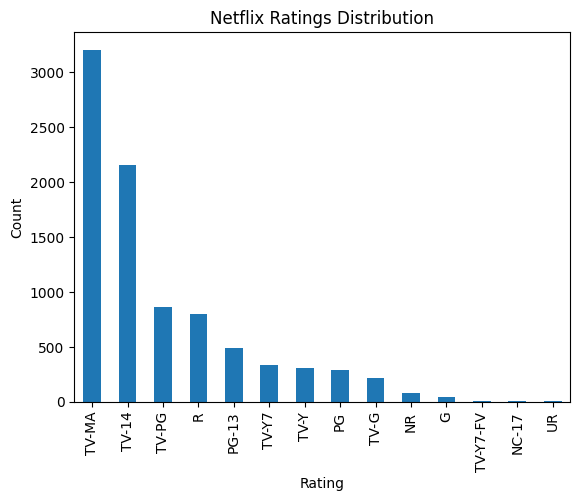

In [20]:
ratings_count = df['rating'].value_counts()
ratings_count.plot(kind='bar')
plt.title("Netflix Ratings Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

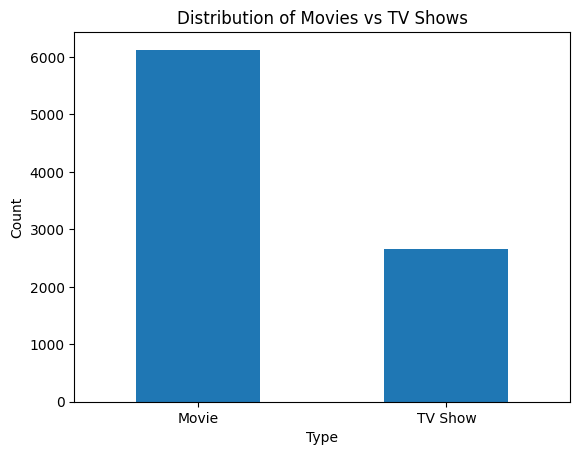

In [21]:
df['type'].value_counts().plot(kind='bar')
plt.title('Distribution of Movies vs TV Shows')
plt.xlabel('Type')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

<Axes: title={'center': 'Release Year Trend'}, xlabel='release_year'>

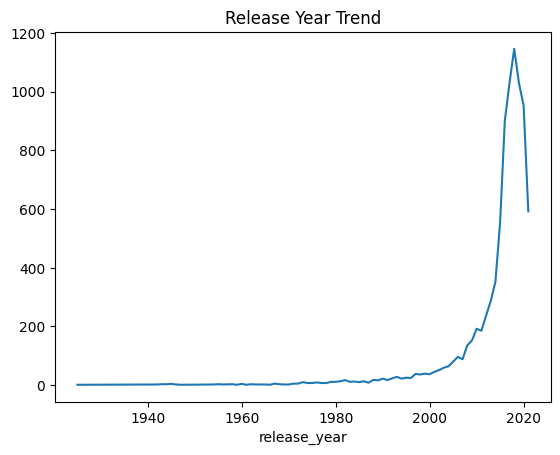

In [22]:
# Release year trend
df['release_year'].value_counts().sort_index().plot(
    kind='line', title='Release Year Trend')

In [23]:
#  Duration Analysis
df[['duration_num', 'duration_type']] = df['duration'].str.split(' ', expand=True)
df['duration_type'].value_counts()

duration_type
min        6126
Season     1791
Seasons     873
Name: count, dtype: int64

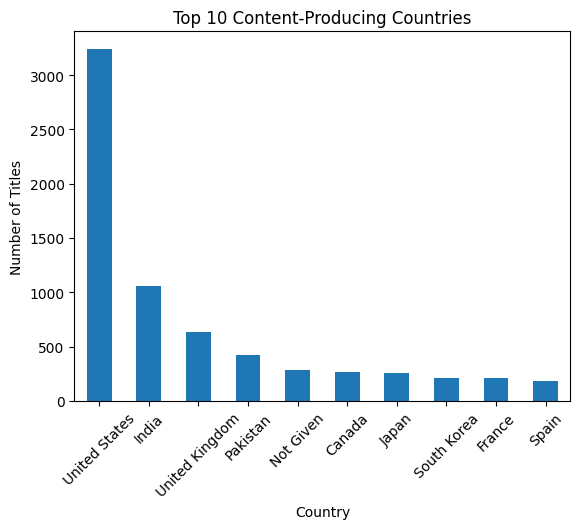

In [24]:
# Top 10 Countries Producing Content - 
# The United States leads content production, followed by countries like India and the UK, highlighting Netflix’s global content strategy.
df['country'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Content-Producing Countries')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.show()


In [25]:
df[['date_added', 'release_year']].describe()

,date_added,release_year
count,8790,8790.000000
mean,2019-05-17 21:44:01.638225,2014.183163
min,2008-01-01 00:00:00,1925.000000
25%,2018-04-06 00:00:00,2013.000000
50%,2019-07-03 00:00:00,2017.000000
75%,2020-08-19 18:00:00,2019.000000
max,2021-09-25 00:00:00,2021.000000
std,NaN,8.825466
